# Quotes Dataset — Exploratory Analysis

**Purpose:** Explore the raw quotes CSV to understand its structure: how `quote_id` sessions
are built from repeated pricing calls, how the A/B £2 price gap is structured, how GPS
coordinates and ETT behave across calls, and what cleaning rules are needed before the data
can be used for demand forecasting. Produces a single deduplicated canonical record per quote.

**Output:** `data/processed/quotes_canonical.parquet`

**What is important for you in this notebook?**

**Key concepts defined:** 

- **`quote_id`** — one customer session (app open → price shown → convert or abandon).
- **Pricing call** — all rows sharing the exact same `quote_creation_timestamp` within a session. In 95.3% of cases call emits more than 2 rows. In 75% of total cases just 2 rows: control arm (£X) and treatment arm (£X + £2). 75 % of sessions have exactly two calls.

**EDA findings:**

- 4.7 % of sessions have a single row; 95.3 % have duplicates.
- Pickup never moves in 92.3 % of sessions; dropoff in 94.4 %.
- ETT is consistent within a single pricing call (only 10 exceptions in 1.47 M calls).

**Cleaning functions rules**

Four filters applied in sequence, then one row per quote is built from the last pricing call.
All thresholds live in `src/config.py`.

| Step | Function | What it removes |
|------|----------|-----------------|
| 1 | `filter_inconsistent_conversion` | ~147 `quote_id`s where `quote_converted` flips between calls |
| 2 | `filter_outside_london` | Any `quote_id` with at least one coordinate outside `BBOX` (London coordinates defined in config) |
| 3 | `filter_location_spread` | `quote_id`s where **pickup** GPS drift across calls exceeds `MAX_SPREAD_M` (1 000 m). Dropoff spread is not filtered, I thought that edits in the dropoff is sth that is done by a rider, in case they accidentelly changed put wrong dropoff. While for pickup locations, I assume that people in most of the cases use their gps location and too large drifts could indentify some gps glitches. |
| 4 | `filter_ett_variation` | `quote_id`s where ETT (estimated time travel) range across pricing calls exceeds `MAX_ETT_DIFF_S` (1 000 s) |

**Canonical location assignment** (`assign_canonical_location`) — every row in a `quote_id` is
overwritten with coordinates from the **final pricing call** (`max(quote_creation_timestamp)`):

- **Pickup** — last-call value. Safe because filter 3 guarantees drift < 1 000 m, so last-call ≈ any-call.
- **Dropoff** — last-call value. Reflects the customer's most recently confirmed destination.

**Canonical one-row-per-quote** (`build_canonical_quotes`) — collapses to one row per `quote_id`
by keeping only the last pricing call rows and randomly sampling one A/B arm from them.
Pickup, dropoff, ETT, and price all come from that last call.


**All Contents**

0. Imports & load raw CSV
1. Duplicate overview — rows-per-`quote_id` distribution, share of single-row sessions
2. Pricing call structure — GPS spread per session, call timing, A/B pair confirmation
3. A/B pricing — verify the £2 gap is consistent across all calls
4. Estimated travel time — ETT consistency within a call and variation across calls
6. Cleaning pipeline — four sequential filters + canonical location assignment + save

In [1]:
cd ..

/Users/deryadurmush/git/av_fleet


/Users/deryadurmush/.pyenv/versions/iom-migration-foresight-dssgx-24/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## 0. Imports & load

In [ ]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.quotes_cleaning import  max_spread_m

TRIPS_FILE = 'data/raw/THA_Dataset_MarketplaceDS.csv'

df = pd.read_csv(TRIPS_FILE, parse_dates=['quote_creation_timestamp'])
df['quote_creation_timestamp'] = pd.to_datetime(df['quote_creation_timestamp'], utc=True)

print(f'Rows:          {len(df):,}')
print(f'Unique IDs:    {df["quote_id"].nunique():,}')
print(f'Columns:       {list(df.columns)}')
print(f'Date range:    {df["quote_creation_timestamp"].min()}  →  {df["quote_creation_timestamp"].max()}')
df.head(3)


Rows:          2,095,553
Unique IDs:    543,624
Columns:       ['quote_id', 'quote_creation_timestamp', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'quoted_price', 'estimated_travel_time', 'quote_converted']
Date range:    2026-03-01 00:00:02.826000+00:00  →  2026-03-31 23:59:56.763000+00:00


,quote_id,quote_creation_timestamp,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,quoted_price,estimated_travel_time,quote_converted
0,N2ZlMWQwOT,2026-03-06 15:45:29.562000+00:00,-0.179,51.495,-0.200,51.500,15.83,585,True
1,ODliYWZlMD,2026-03-06 15:24:24.949000+00:00,-0.173,51.556,-0.159,51.546,13.59,446,False
2,MDE5ZDVhND,2026-03-06 15:04:03.710000+00:00,-0.096,51.542,-0.172,51.546,32.83,1735,False


## 1. Duplicate overview

In [4]:
rows_per_id = df.groupby('quote_id').size().rename('rows_per_id')

total_ids   = len(rows_per_id)
unique_ids  = (rows_per_id == 1).sum()
dup_ids     = (rows_per_id > 1).sum()
rows_in_dup = rows_per_id[rows_per_id > 1].sum()

print('=== Duplication summary ===')
print(f'Total rows:                {len(df):>10,}')
print(f'Unique quote_ids:          {total_ids:>10,}')
print(f'  → appear exactly once:   {unique_ids:>10,}  ({unique_ids/total_ids*100:.1f}%)')
print(f'  → appear 2+ times:       {dup_ids:>10,}  ({dup_ids/total_ids*100:.1f}%)')
print(f'Rows that are duplicated:  {rows_in_dup:>10,}  ({rows_in_dup/len(df)*100:.1f}% of all rows)')

=== Duplication summary ===
Total rows:                 2,095,553
Unique quote_ids:             543,624
  → appear exactly once:       25,665  (4.7%)
  → appear 2+ times:          517,959  (95.3%)
Rows that are duplicated:   2,069,888  (98.8% of all rows)


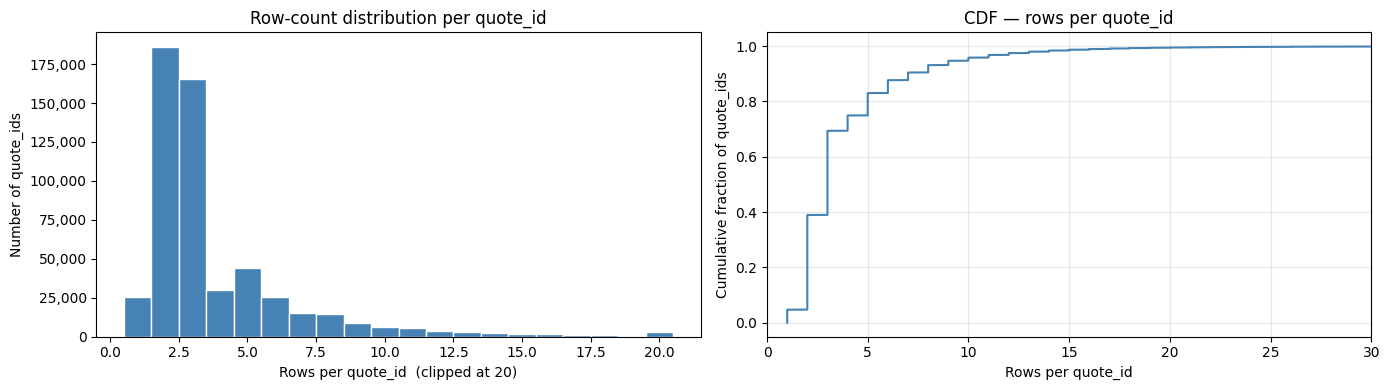

In [5]:
# Distribution of how many rows each quote_id has
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram clipped at 20 for readability
clipped = rows_per_id.clip(upper=20)
axes[0].hist(clipped, bins=range(1, 22), edgecolor='white', color='steelblue', align='left')
axes[0].set_xlabel('Rows per quote_id  (clipped at 20)')
axes[0].set_ylabel('Number of quote_ids')
axes[0].set_title('Row-count distribution per quote_id')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: CDF
sorted_counts = np.sort(rows_per_id.values)
cdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1].plot(sorted_counts, cdf, color='steelblue')
axes[1].set_xlim(0, 30)
axes[1].set_xlabel('Rows per quote_id')
axes[1].set_ylabel('Cumulative fraction of quote_ids')
axes[1].set_title('CDF — rows per quote_id')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_rows_per_id.png', dpi=150)
plt.show()

## 2. Pricing call structure

**Pricing call** = all rows with the **exact same `quote_creation_timestamp`** within a `quote_id`.  

In [9]:

# Within each quote_id, rank unique timestamps sequentially (0, 1, 2, ...).
# Rows sharing the exact same timestamp get the same call_num.
df_calls = df.copy()
df_calls['call_num'] = (
    df_calls.groupby('quote_id')['quote_creation_timestamp']
    .transform(lambda s: s.rank(method='dense').astype(int) - 1)
)

# ── Check 1: quote_converted consistent within one pricing call ────────────────
mixed_within_call = (
    df_calls.groupby(['quote_id', 'call_num'])['quote_converted']
    .nunique()
    .gt(1)
    .sum()
)
total_calls = df_calls.groupby(['quote_id', 'call_num']).ngroups

print('=== quote_converted within one pricing call ===')
print(f'  Total pricing calls:        {total_calls:,}')
print(f'  Calls with mixed values:    {mixed_within_call}')
print(f'  → Always consistent: {mixed_within_call == 0}')
print()

# ── Check 2: quote_converted consistent within the whole quote_id ──────────────
mixed_within_quote = (
    df_calls.groupby('quote_id')['quote_converted']
    .nunique()
    .gt(1)
    .sum()
)
total_quotes = df_calls['quote_id'].nunique()

print('=== quote_converted across all calls of a quote_id ===')
print(f'  Total quote_ids:            {total_quotes:,}')
print(f'  quote_ids with mixed values: {mixed_within_quote}')
print(f'  → Always consistent: {mixed_within_quote == 0}')


=== quote_converted within one pricing call ===
  Total pricing calls:        1,475,906
  Calls with mixed values:    0
  → Always consistent: True

=== quote_converted across all calls of a quote_id ===
  Total quote_ids:            543,624
  quote_ids with mixed values: 147
  → Always consistent: False


In [ ]:
# ── Pickup and dropoff spread per quote_id ────────────────────────────────────

def _spread(df_raw, lat_col, lon_col):
    return (
        df_raw.groupby('quote_id')
        .apply(lambda g: max_spread_m(g[lat_col].to_numpy(), g[lon_col].to_numpy()))
        .rename('max_dist_m')
        .reset_index()
    )

pickup_spread  = _spread(df, 'pickup_latitude',  'pickup_longitude')
dropoff_spread = _spread(df, 'dropoff_latitude', 'dropoff_longitude')

for name, sp in [('Pickup', pickup_spread), ('Dropoff', dropoff_spread)]:
    n_static = (sp['max_dist_m'] == 0).sum()
    london   = sp[sp['max_dist_m'] < 40_000]
    print(f'=== Finding: {name} spread per quote_id ===')
    print(f'  Never moves (static):  {n_static:,} / {len(sp):,}  ({100*n_static/len(sp):.1f} %)')
    print(f'  Mean max spread:       {london["max_dist_m"].mean():.0f} m  (London-only, excl. GPS outliers)')
    print(f'  Median max spread:     {london["max_dist_m"].median():.0f} m')
    print()

# ── Summary ───────────────────────────────────────────────────────────────────
n_pu_static = (pickup_spread['max_dist_m'] == 0).sum()
n_do_static = (dropoff_spread['max_dist_m'] == 0).sum()
print('=' * 65)
print('SUMMARY')
print('=' * 65)
print(f'Pickup  never moves:   {n_pu_static:,} / {len(pickup_spread):,}  ({100*n_pu_static/len(pickup_spread):.1f} %)')
print(f'Dropoff never moves:   {n_do_static:,} / {len(dropoff_spread):,}  ({100*n_do_static/len(dropoff_spread):.1f} %)')
pu_london = pickup_spread[pickup_spread['max_dist_m'] < 40_000]
do_london = dropoff_spread[dropoff_spread['max_dist_m'] < 40_000]
print(f'Pickup  median spread: {pu_london["max_dist_m"].median():.0f} m  (London-only)')
print(f'Dropoff median spread: {do_london["max_dist_m"].median():.0f} m  (London-only)')


=== Finding: Pickup spread per quote_id ===
  Never moves (static):  501,917 / 543,624  (92.3 %)
  Mean max spread:       79 m  (London-only, excl. GPS outliers)
  Median max spread:     0 m

=== Finding: Dropoff spread per quote_id ===
  Never moves (static):  513,051 / 543,624  (94.4 %)
  Mean max spread:       298 m  (London-only, excl. GPS outliers)
  Median max spread:     0 m

SUMMARY
Pickup  never moves:   501,917 / 543,624  (92.3 %)
Dropoff never moves:   513,051 / 543,624  (94.4 %)
Pickup  median spread: 0 m  (London-only)
Dropoff median spread: 0 m  (London-only)


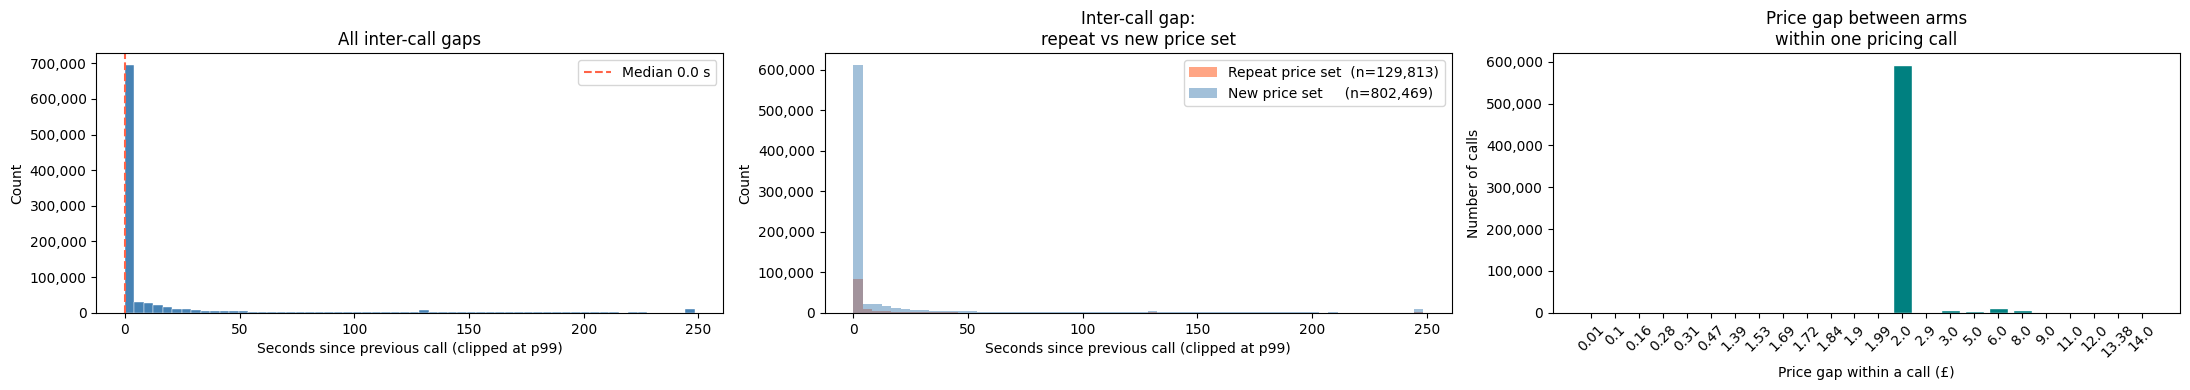

Inter-call gap summary (seconds):
count     932282.00
mean         277.59
std        18428.34
min            0.00
25%            0.00
50%            0.00
75%            4.82
max      2518133.45
Name: gap_s, dtype: float64


In [ ]:
# ── Time between consecutive calls 

call_stats = (
    df_calls.groupby(['quote_id', 'call_num'])
    .agg(
        call_ts=('quote_creation_timestamp', 'first'),
        prices=('quoted_price', lambda x: sorted(set(x))),
    )
    .reset_index()
    .sort_values(['quote_id', 'call_num'])
)

call_stats['gap_s']       = (
    call_stats['call_ts']
    - call_stats.groupby('quote_id')['call_ts'].shift(1)
).dt.total_seconds()

call_stats['prev_prices'] = call_stats.groupby('quote_id')['prices'].shift(1)
call_stats['is_repeat']   = [
    frozenset(cur) == frozenset(prev) if isinstance(prev, list) else False
    for cur, prev in zip(call_stats['prices'], call_stats['prev_prices'])
]
call_stats['price_gaps']  = call_stats['prices'].apply(
    lambda p: [round(p[i+1] - p[i], 2) for i in range(len(p) - 1)]
)

non_first       = call_stats[call_stats['call_num'] > 0]
all_gaps_s      = non_first['gap_s'].dropna()
repeat_gaps_s   = non_first[non_first['is_repeat']]['gap_s'].dropna()
norepeat_gaps_s = non_first[~non_first['is_repeat']]['gap_s'].dropna()

clip_s = all_gaps_s.quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(22, 4))

axes[0].hist(all_gaps_s.clip(upper=clip_s), bins=60,
             color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(all_gaps_s.median(), color='tomato', linestyle='--',
                label=f'Median {all_gaps_s.median():.1f} s')
axes[0].set_xlabel('Seconds since previous call (clipped at p99)')
axes[0].set_ylabel('Count')
axes[0].set_title('All inter-call gaps')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(repeat_gaps_s.clip(upper=clip_s),   bins=60, alpha=0.7,
             label=f'Repeat price set  (n={len(repeat_gaps_s):,})', color='coral')
axes[1].hist(norepeat_gaps_s.clip(upper=clip_s), bins=60, alpha=0.5,
             label=f'New price set     (n={len(norepeat_gaps_s):,})', color='steelblue')
axes[1].set_xlabel('Seconds since previous call (clipped at p99)')
axes[1].set_ylabel('Count')
axes[1].set_title('Inter-call gap:\nrepeat vs new price set')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

all_price_gaps = [g for gaps in call_stats['price_gaps'] for g in gaps]
gap_counts = pd.Series(all_price_gaps).value_counts().sort_index()
axes[2].bar(gap_counts.index.astype(str), gap_counts.values,
            color='teal', edgecolor='white')
axes[2].set_xlabel('Price gap within a call (£)')
axes[2].set_ylabel('Number of calls')
axes[2].set_title('Price gap between arms\nwithin one pricing call')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print('Inter-call gap summary (seconds):')
print(all_gaps_s.describe().round(2))


## 3. A/B pricing — the £2 gap

Every pricing call emits two rows with a fixed £2 price difference.
This section confirms the gap is structural, not noise, and checks that
`quote_converted` is consistent across both arms.

In [13]:
price_stats = (
    df.groupby('quote_id')['quoted_price']
    .agg(n_prices='nunique', min_price='min', max_price='max')
)
price_stats['price_range'] = price_stats['max_price'] - price_stats['min_price']

print('=== Price variants per quote_id ===')
print(price_stats['n_prices'].value_counts().sort_index().to_string())
print()
print(f'Quotes with >1 distinct price: {(price_stats["n_prices"] > 1).sum():,}')
print(f'  as % of all quote_ids:       {(price_stats["n_prices"] > 1).mean()*100:.1f}%')

=== Price variants per quote_id ===
n_prices
1      28885
2     408217
3      16817
4      67790
5       1136
6      14451
7        358
8       3091
9        948
10       964
11        55
12       421
13        18
14       184
15        21
16        76
17         8
18        73
19         4
20        31
21         5
22        20
23         1
24         8
26        10
27         3
28         5
29         1
30         5
32         4
34         3
36         5
38         3
39         1
42         1
62         1

Quotes with >1 distinct price: 514,739
  as % of all quote_ids:       94.7%


In [27]:
len(price_stats[price_stats['n_prices'] == 2])/len(price_stats)

0.7509179138522214

In [14]:
# Compute all consecutive price gaps within each quote_id
sorted_prices = (
    df.groupby('quote_id')['quoted_price']
    .apply(lambda s: sorted(s.unique()))
)

gaps = []
for prices in sorted_prices:
    for a, b in zip(prices, prices[1:]):
        gaps.append(round(b - a, 2))

gap_series = pd.Series(gaps)
print('=== Top 20 price gap values ===')
print(gap_series.value_counts().head(20).to_string())

=== Top 20 price gap values ===
2.00    479344
6.00      8401
0.01      7911
0.02      7343
0.03      6828
0.04      6290
0.05      5615
0.06      5105
0.07      4788
3.00      4505
0.08      4406
0.09      4195
0.10      4181
0.11      3753
0.12      3535
0.13      3259
0.14      2957
0.15      2883
0.16      2787
0.17      2646


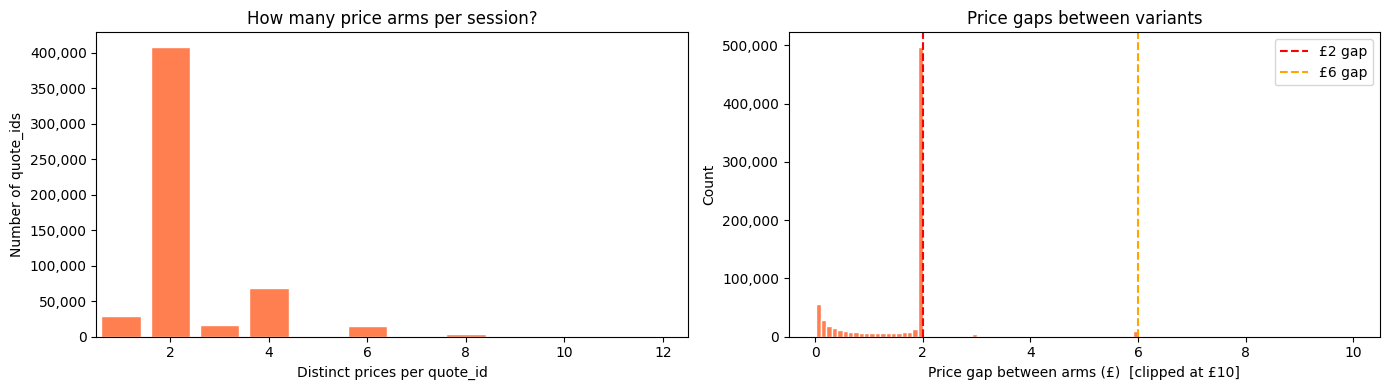

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: number of distinct prices per quote
n_price_counts = price_stats['n_prices'].value_counts().sort_index()
axes[0].bar(n_price_counts.index, n_price_counts.values, color='coral', edgecolor='white')
axes[0].set_xlabel('Distinct prices per quote_id')
axes[0].set_ylabel('Number of quote_ids')
axes[0].set_title('How many price arms per session?')
axes[0].set_xlim(0.5, 12.5)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: gap distribution (clip at £10 for readability, highlight £2 and £6)
clipped_gaps = gap_series[gap_series <= 10]
axes[1].hist(clipped_gaps, bins=100, color='coral', edgecolor='white')
axes[1].axvline(2.0, color='red',    linestyle='--', linewidth=1.5, label='£2 gap')
axes[1].axvline(6.0, color='orange', linestyle='--', linewidth=1.5, label='£6 gap')
axes[1].set_xlabel('Price gap between arms (£)  [clipped at £10]')
axes[1].set_ylabel('Count')
axes[1].set_title('Price gaps between variants')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('eda_price_variants.png', dpi=150)
plt.show()

## 4. `estimated_travel_time` — how it varies across calls

**Within a single pricing call (exact timestamp):** ETT is always identical — all rows in a call share the same ETT (only 10 exceptions in 1.47M calls).


**Key relationship:** ETT and price move together. When ETT increases between reloads, price increases ~74% of the time. The base pricing is ETT-driven.

In [16]:
# ── ETT per pricing call (one value per call — identical within a call) ────────
# Use build_call_table output if available, otherwise derive from df directly
ett_per_call = (
    df.groupby(['quote_id', 'quote_creation_timestamp'])['estimated_travel_time']
    .first()
    .reset_index()
    .rename(columns={'estimated_travel_time': 'ett'})
    .sort_values(['quote_id', 'quote_creation_timestamp'])
)

# Verify ETT is consistent within a call
ett_spread_within_call = (
    df.groupby(['quote_id', 'quote_creation_timestamp'])['estimated_travel_time']
    .nunique()
)
print(f'Calls where ETT varies within exact timestamp: {(ett_spread_within_call > 1).sum()}')
print(f'Total calls: {len(ett_spread_within_call):,}')

Calls where ETT varies within exact timestamp: 10
Total calls: 1,475,906


In [17]:
# ── ETT range within each quote_id ────────────────────────────────────────────


quote_ett = (
    df.groupby("quote_id")["estimated_travel_time"]
    .agg(ett_min="min", ett_max="max", n_calls="count")
)
quote_ett["ett_range_sec"] = quote_ett["ett_max"] - quote_ett["ett_min"]

multi_call = quote_ett[quote_ett["n_calls"] > 1]
stable     = (multi_call["ett_range_sec"] == 0).sum()
changing   = (multi_call["ett_range_sec"] >  0).sum()

print(f"quote_ids with >1 call:                    {len(multi_call):,}")
print(f"  ETT completely stable (range = 0):       {stable:,}  ({stable/len(multi_call)*100:.1f}%)")
print(f"  ETT varies across calls:                 {changing:,}  ({changing/len(multi_call)*100:.1f}%)")
print()

nz = multi_call[multi_call["ett_range_sec"] > 0]["ett_range_sec"]
print(f"When ETT varies — range (max-min) across calls:")
print(f"  Median: {nz.median():.0f} s  ({nz.median()/60:.1f} min)")
print(f"  Mean:   {nz.mean():.0f} s  ({nz.mean()/60:.1f} min)")
print(f"  95th pct: {nz.quantile(0.95):.0f} s  ({nz.quantile(0.95)/60:.1f} min)")

quote_ids with >1 call:                    517,959
  ETT completely stable (range = 0):       425,236  (82.1%)
  ETT varies across calls:                 92,723  (17.9%)

When ETT varies — range (max-min) across calls:
  Median: 79 s  (1.3 min)
  Mean:   533 s  (8.9 min)
  95th pct: 2169 s  (36.1 min)



## 6. Cleaning pipeline

Four filters applied in sequence, then one row per quote is built from the last pricing call.
All thresholds live in `src/config.py`.

| Step | Function | What it removes |
|------|----------|-----------------|
| 1 | `filter_inconsistent_conversion` | ~147 `quote_id`s where `quote_converted` flips between calls |
| 2 | `filter_outside_london` | Any `quote_id` with at least one coordinate outside `BBOX` |
| 3 | `filter_location_spread` | `quote_id`s where **pickup** GPS drift across calls exceeds `MAX_SPREAD_M` (1 000 m). Dropoff spread is not filtered — changes are deliberate destination edits, not noise. |
| 4 | `filter_ett_variation` | `quote_id`s where ETT range across pricing calls exceeds `MAX_ETT_DIFF_S` (1 000 s) |

**Canonical location assignment** (`assign_canonical_location`) — every row in a `quote_id` is
overwritten with coordinates from the **final pricing call** (`max(quote_creation_timestamp)`):

- **Pickup** — last-call value. Safe because filter 3 guarantees drift < 1 000 m, so last-call ≈ any-call.
- **Dropoff** — last-call value. Reflects the customer's most recently confirmed destination.
  Averaging would blend distinct destinations into a meaningless midpoint.

**Canonical one-row-per-quote** (`build_canonical_quotes`) — collapses to one row per `quote_id`
by keeping only the last pricing call rows and randomly sampling one A/B arm from them.
Pickup, dropoff, ETT, and price all come from that last call.

## CLEANING

In [ ]:
from src.quotes_cleaning import (
    run_pipeline,
    assign_canonical_location,
    build_and_save_canonical,
    check_quote_consistency,
)
from src.config import QUOTES_CANONICAL_FILE

# run all four cleaning filters ───────────────────────────────────
df_clean = run_pipeline(df)

# assign canonical locations (both pickup & dropoff = last call) ────
df_clean = assign_canonical_location(df_clean)


=== Quotes cleaning pipeline ===
Input:  2,095,553 rows  |  543,624 quote_ids

[filter_inconsistent_conversion]  dropped 147 quote_ids (543,624 → 543,477)
[filter_outside_london]           dropped 14,001 quote_ids (543,477 → 529,476)
[filter_location_spread]          dropped 24,298 quote_ids (spread > 1000 m)  (529,476 → 505,178)
[filter_ett_variation]            dropped 2,815 quote_ids (ETT range > 1000 s)  (505,178 → 502,363)

Output: 1,860,925 rows  |  502,363 quote_ids  (41,261 removed in total)
[assign_canonical_location]       canonicalised coordinates for 34,289 quote_ids with location drift


In [ ]:
# consistency check 
report = check_quote_consistency(df_clean)
assert report["all_ok"], f"Consistency check failed: {report}"



[check_quote_consistency]  PASS  (502,363 quote_ids)
  quote_converted consistent:   True  (violations: 0)
  pickup  location consistent:  True  (violations: 0)
  dropoff location consistent:  True  (violations: 0)


In [ ]:
build_and_save_canonical(
    cleaned_csv_path=QUOTES_CLEANED_FILE,
    output_path=QUOTES_CANONICAL_FILE,
)
